In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
def data1():
    X=pd.read_csv('state_after_kmeans.csv')
    X = X.iloc[100:]  # Keep rows from index 19 onwards (0-based index)
    # Ensure 'Open' and 'Close' are treated as numeric
    X['cashopen']=0
    X['cash']=0
    # Ensure columns have float dtype before assignment
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [3]:
X=data1()

In [4]:
print(len(X))

2845


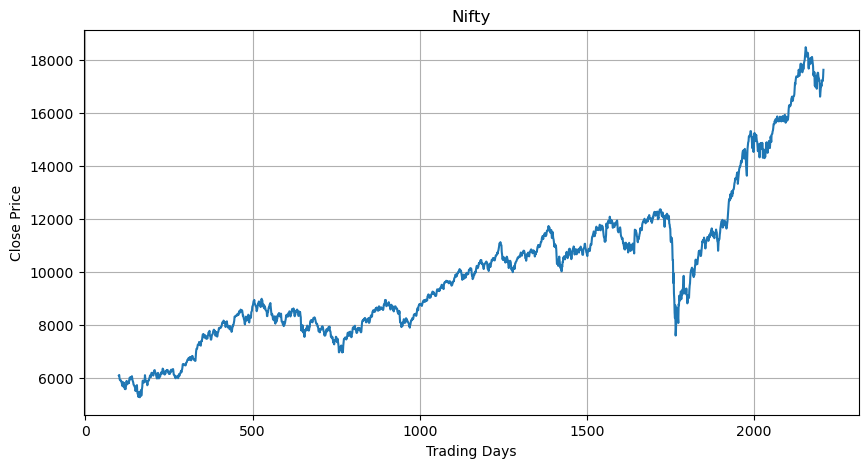

In [5]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure()
ax=X.loc[100:2207,'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
#fig.savefig('nifty_close.png')

In [6]:
X.head()

,Unnamed: 0,Close,High,Low,Open,Volume,date,weekday,month,SMA_10,...,CMF_20,FI_13,VROC_10,PVT,Cluster,cashopen,cash,action,diff,quantity
100,100,6104.299805,6125.049805,6069.799805,6120.450195,120200,29-05-2013,2,5,6097.199902,...,0.097321,-8.354134e+05,-21.897336,-3061.705179,0.0,0.0,0.0,,,
101,101,6124.049805,6133.750000,6072.149902,6072.149902,194100,30-05-2013,3,5,6092.614893,...,0.107417,3.833475e+06,22.383354,-2433.709319,0.0,0.0,0.0,,,
102,102,5985.950195,6106.250000,5975.549805,6098.700195,175300,31-05-2013,4,5,6072.479932,...,0.084902,-2.420886e+07,19.008826,-6386.789782,0.0,0.0,0.0,,,
103,103,5939.299805,6011.000000,5916.350098,5997.350098,112100,03-06-2013,0,6,6050.719922,...,0.033256,-5.229509e+06,-8.340147,-7260.420291,0.0,0.0,0.0,,,
104,104,5919.450195,5981.600098,5910.250000,5941.100098,114500,04-06-2013,1,6,6031.254932,...,-0.036799,-2.272780e+06,-12.327718,-7643.088353,0.0,0.0,0.0,,,


In [7]:
X['Cluster'].value_counts()

Cluster
0.0    1648
1.0     736
4.0     276
3.0     168
5.0       9
2.0       8
Name: count, dtype: int64

In [8]:
#X.head()

In [9]:
def getState(t):
    t = int(t)
    return(X['Cluster'][t])  

In [10]:
class Agent:
    def __init__(self):
        self.epsilon = 1.0
        self.gamma = 0.618
        self.epsilon_decay = 0.999
        self.epsilon_min = 0.01
        self.Q = np.matrix(np.zeros([6,3]))
        self.learning_rate=0.03
        
    def getAction(self,state):
        state = int(state)
        a=[1,0,2]
        if np.random.rand() <= self.epsilon:
            return random.choice(a)
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
        state = int(state)
        action = int(action)
        next_state = int(next_state)
        self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [11]:
episode_count=100
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=101
    data_length=2355
    state = getState(data_length_start-1)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    #X.loc[2,'cashopen']=margin 
    X.loc[2, 'cashopen'] = float(margin)
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=float(margin)
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
            
       
        elif action == 2:
            X.loc[t,'cashopen']=float(margin) 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
           
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
        #print(f"getState({t+1}) = '{getState(t+1)}' (Type: {type(getState(t+1))})")    
        next_state=int(getState(t))
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n",t)
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
        if (agent.epsilon > agent.epsilon_min) and e>1:
                       agent.epsilon *= agent.epsilon_decay
                       
    
    m3=roi
    if m3>m2:
        m1=e
        m2=m3
    #To save model  
    if e%20==0:
        np.save('rl/Qtable'+ str(e)+str('.npy'), agent.Q)
        np.save('rl/epsilon'+ str(e)+str('.npy'), agent.epsilon)
        np.save('rl/gamma'+ str(e)+str('.npy'), agent.gamma)
        np.save('rl/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
        X.to_csv('csv1/AfterTrain'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

Episod 1/100

***********************
 2206
Profit is  5872.44397800033
Initial Capital is  60721.49902
Current Capital is  66593.94299800033
%ROI is  9.671111670128743
% Buy and Hold= 185.79746976081816
count 1376
qtable [[3.56623429e-03 6.18176600e-03 7.72009814e-03]
 [1.69971256e-03 2.73222352e-03 3.04352863e-03]
 [3.92508434e-05 3.14185554e-03 1.17497972e-03]
 [1.84462591e-03 5.75660183e-03 6.08973893e-03]
 [2.34869183e-03 6.15029648e-03 5.91728820e-03]
 [2.50164741e-04 2.29094182e-04 1.25407505e-04]]
epsilon 1.0
--------------------------------
Episod 2/100

***********************
 2206
Profit is  34389.82412800004
Initial Capital is  60721.49902
Current Capital is  95111.32314800004
%ROI is  56.63533457346461
% Buy and Hold= 185.79746976081816
count 1785
qtable [[0.00489876 0.00746934 0.01181693]
 [0.00237001 0.0035122  0.00789708]
 [0.00018473 0.00574012 0.00131682]
 [0.002425   0.00596763 0.00990014]
 [0.00328116 0.00711674 0.00726798]
 [0.00099208 0.00058156 0.00012541]]
epsi

In [12]:
agent.Q

matrix([[0.00534377, 0.00539617, 0.01250951],
        [0.0050824 , 0.00703177, 0.00960062],
        [0.0007795 , 0.02609324, 0.00166725],
        [0.00529707, 0.00949533, 0.01199423],
        [0.0060579 , 0.00860893, 0.0088408 ],
        [0.00899429, 0.00107323, 0.0018761 ]])

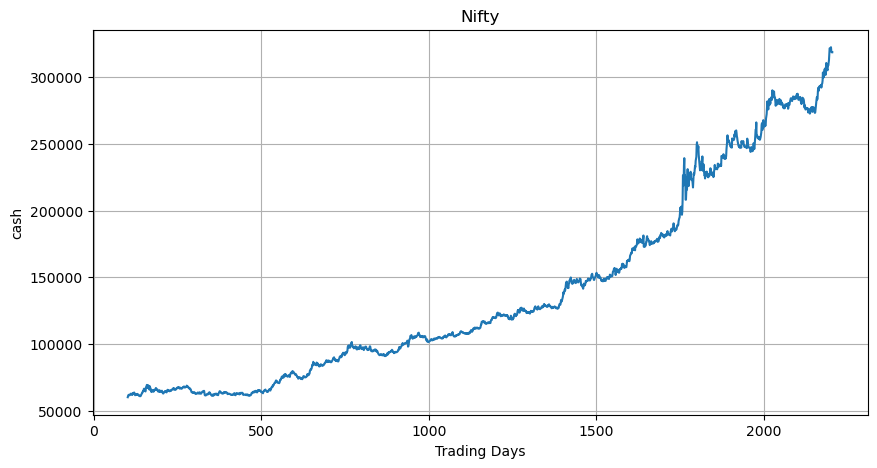

In [13]:
%matplotlib inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-2,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()